# Week 7: HealthConnect Experience Lab
## Model Testing, Error Analysis & Refinement

**AnalystLab Africa - Experience Lab Internship Programme | Data Science Track**

**Project:** HealthConnect Clinic Experience Lab - Improving Patient Appointment Attendance and Healthcare Support Using Data and AI

Week 6 produced a candidate model - a tuned Gradient Boosting classifier - through error analysis, a feature fix, cross-track integration, and hyperparameter tuning. Per the Week 7 brief, this notebook does **not** repeat that work. It **tests** the Week 6 candidate systematically against the five concrete testing requirements Week 6 itself identified, **refines** based on what those tests actually find, and **re-tests** the result - including one finding that changes the Week 6 recommendation rather than just confirming it.


## Part 1: Week 6 -> Week 7 Transition

**1. Main Week 6 output:** `week6_model_improvement.ipynb` - fixed the `personal_noshow_rate` sentinel-value issue, integrated a `reminder_channel` feature from a Data-Analytics-style finding, ran 5-fold patient-grouped cross-validation, and tuned Random Forest and Gradient Boosting candidates.

**2. Most important result:** a **tuned Gradient Boosting** model was recommended as the Week 7 candidate - 65.2% recall, 0.645 F1, 0.689 ROC-AUC on the held-out test set, a modest improvement over the Week 5 baseline (64.6% recall, 0.634 F1, 0.679 ROC-AUC).

**3. Main issue/limitation discovered in Week 6:** a *new* multicollinearity issue between the fixed `personal_noshow_rate_v2` and its own raw-count inputs (`previous_no_shows`, `previous_appointments`), plus higher error rates in the Specialist Consultation and 65+ segments that weren't yet explained.

**4. Component requiring testing:** the tuned Gradient Boosting candidate model itself, and the provisional `reminder_channel` cross-track finding it depends on.

**5. Track(s) relevant to Week 7 activities:** Data Science (this notebook) and Data Analytics (the HC-POD cross-track testing activity in Part 7).

**6. What this notebook tests:** the five concrete testing requirements Week 6's own Part 12 listed - multicollinearity resolution, segment-level performance with confidence intervals, a threshold analysis, a stability check across different data splits, and independent robustness-checking of the `reminder_channel` finding.

**7. What is expected to improve or be validated:** at least one genuine, evidence-based refinement to the candidate model or its operating configuration, carried through a full test -> finding -> action -> retest cycle - not simply a restatement of Week 6's results.


In [1]:
import warnings
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    precision_recall_curve
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42


## Part 2: Week 7 Testing Readiness

**A. Component being tested:** the Week 6 tuned Gradient Boosting candidate model, trained on the refined feature set (fixed `personal_noshow_rate_v2` + `reminder_channel`), and the provisional `reminder_channel` finding it depends on.

**B. Testing objective:** determine whether the Week 6 candidate model's reported improvement is robust and where, specifically, it still performs unreliably - rather than accepting the Week 6 headline numbers as final.

**C. Test plan**

| # | Test / Scenario | Expected Result |
|---|---|---|
| 1 | Resolve `personal_noshow_rate_v2` multicollinearity by dropping the raw counts it's derived from | Similar or better performance with a cleaner, less redundant feature set |
| 2 | Segment-level recall with 95% bootstrap confidence intervals (Specialist Consultation, 65+) | Confirm whether the Week 6-flagged underperformance is statistically real or just a small-sample artefact |
| 3 | Threshold analysis (0.35-0.60) | Identify whether the default 0.5 cutoff is actually the best operating point for HealthConnect's recall-favouring use case |
| 4 | Stability check - rerun the group split with different random seeds | Confirm the Gradient Boosting candidate's edge over the Logistic Regression baseline holds beyond the one split Week 6 reported |
| 5 | Robustness check on the `reminder_channel` finding (no real Data Analytics deliverable exists yet) | Determine whether the channel-level distinction is statistically solid enough to keep, or should be simplified |

Each test below is followed by its actual result, not the expected one - Section D of the brief requires real evidence, not a description of what was planned.


## Part 3: The Model Under Test

The Week 6 candidate is reproduced exactly - same data, same refined features, same tuned hyperparameters, same patient-grouped split - so the tests below run against the real Week 6 artefact rather than a re-derived approximation.


In [2]:
df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df_model = df[df["appointment_outcome"] != "Cancelled"].copy()
df_model["did_not_attend"] = (df_model["appointment_outcome"] == "No-Show").astype(int)
df_model["distance_to_clinic_km"] = df_model["distance_to_clinic_km"].fillna(df_model["distance_to_clinic_km"].median())

df_model["is_new_patient"] = (df_model["previous_appointments"] == 0).astype(int)
df_model["long_lead_flag"] = (df_model["booking_lead_days"] >= 31).astype(int)
df_model["high_risk_combo"] = ((df_model["previous_no_shows"] >= 2) & (df_model["booking_lead_days"] >= 30)).astype(int)

groups = df_model["patient_id"]
y = df_model["did_not_attend"]

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(df_model[["age"]], y, groups))

# Week 6 fix: personal_noshow_rate_v2, using the TRAINING-set mean for new patients (no leakage)
train_rate_mask = df_model.iloc[train_idx]["previous_appointments"] > 0
train_mean_rate = (
    df_model.iloc[train_idx].loc[train_rate_mask, "previous_no_shows"]
    / df_model.iloc[train_idx].loc[train_rate_mask, "previous_appointments"]
).mean()
df_model["personal_noshow_rate_v2"] = np.where(
    df_model["previous_appointments"] > 0,
    df_model["previous_no_shows"] / df_model["previous_appointments"],
    train_mean_rate
)

feature_cols_numeric_v2 = ["age", "booking_lead_days", "previous_appointments", "previous_no_shows",
                           "distance_to_clinic_km", "personal_noshow_rate_v2", "is_new_patient",
                           "long_lead_flag", "high_risk_combo"]
feature_cols_categorical_v2 = ["gender", "appointment_type", "appointment_day", "appointment_time",
                               "reminder_sent", "reminder_channel"]

X_v2 = df_model[feature_cols_numeric_v2 + feature_cols_categorical_v2]
X_train_v2, X_test_v2 = X_v2.iloc[train_idx], X_v2.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

preprocessor_v2 = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_v2),
])

gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X_train_v2, y_train, groups_train))

gb_pipe = Pipeline([("preprocessing", preprocessor_v2), ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_param_dist = {
    "classifier__n_estimators": [100, 150, 200, 300],
    "classifier__max_depth": [2, 3, 4],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__min_samples_leaf": [1, 5, 10, 20],
    "classifier__subsample": [0.7, 0.85, 1.0],
}
gb_search = RandomizedSearchCV(gb_pipe, gb_param_dist, n_iter=15, scoring="roc_auc", cv=cv_splits, random_state=RANDOM_STATE, n_jobs=-1)
gb_search.fit(X_train_v2, y_train)
best_gb = gb_search.best_estimator_

y_pred_gb = best_gb.predict(X_test_v2)
y_proba_gb = best_gb.predict_proba(X_test_v2)[:, 1]

print("Reproduced Week 6 candidate (Tuned Gradient Boosting):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f} | Precision: {precision_score(y_test, y_pred_gb):.3f} | "
      f"Recall: {recall_score(y_test, y_pred_gb):.3f} | F1: {f1_score(y_test, y_pred_gb):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.3f}")
print("\n(Matches the Week 6 report's 0.641 / 0.638 / 0.652 / 0.645 / 0.689 - confirms this is testing the actual Week 6 artefact.)")


Reproduced Week 6 candidate (Tuned Gradient Boosting):
Accuracy: 0.641 | Precision: 0.638 | Recall: 0.652 | F1: 0.645 | ROC-AUC: 0.689

(Matches the Week 6 report's 0.641 / 0.638 / 0.652 / 0.645 / 0.689 - confirms this is testing the actual Week 6 artefact.)


## Part 4: Test 1 - Resolving the `personal_noshow_rate_v2` Multicollinearity


In [3]:
corr_check = df_model[["personal_noshow_rate_v2", "previous_no_shows", "previous_appointments"]].corr()
print("Correlation matrix:")
print(corr_check.round(3))


Correlation matrix:
                         personal_noshow_rate_v2  previous_no_shows  \
personal_noshow_rate_v2                    1.000              0.775   
previous_no_shows                          0.775              1.000   
previous_appointments                      0.033              0.461   

                         previous_appointments  
personal_noshow_rate_v2                  0.033  
previous_no_shows                        0.461  
previous_appointments                    1.000  


**Test:** retrain the candidate using the same tuned hyperparameters, but with `previous_no_shows` and `previous_appointments` dropped - keeping only `personal_noshow_rate_v2` and `is_new_patient` to carry that information.


In [4]:
feature_cols_numeric_v3 = ["age", "booking_lead_days", "distance_to_clinic_km",
                           "personal_noshow_rate_v2", "is_new_patient", "long_lead_flag", "high_risk_combo"]

X_v3 = df_model[feature_cols_numeric_v3 + feature_cols_categorical_v2]
X_train_v3, X_test_v3 = X_v3.iloc[train_idx], X_v3.iloc[test_idx]

preprocessor_v3 = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric_v3),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_v2),
])

tuned_params = {k: v for k, v in best_gb.named_steps["classifier"].get_params().items()
                if k in ["n_estimators", "max_depth", "learning_rate", "min_samples_leaf", "subsample"]}

model_v3 = Pipeline([("preprocessing", preprocessor_v3), ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE, **tuned_params))])
model_v3.fit(X_train_v3, y_train)
y_pred_v3 = model_v3.predict(X_test_v3)
y_proba_v3 = model_v3.predict_proba(X_test_v3)[:, 1]

test1_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "With raw counts (Week 6 candidate)": [
        accuracy_score(y_test, y_pred_gb), precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb), f1_score(y_test, y_pred_gb), roc_auc_score(y_test, y_proba_gb)],
    "Without raw counts (rate + flag only)": [
        accuracy_score(y_test, y_pred_v3), precision_score(y_test, y_pred_v3),
        recall_score(y_test, y_pred_v3), f1_score(y_test, y_pred_v3), roc_auc_score(y_test, y_proba_v3)],
}).round(3)
test1_table


,Metric,With raw counts (Week 6 candidate),Without raw counts (rate + flag only)
0,Accuracy,0.641,0.636
1,Precision,0.638,0.633
2,Recall,0.652,0.644
3,F1-score,0.645,0.639
4,ROC-AUC,0.689,0.686


**Test 1 result: FAIL to improve (correlation confirmed, but the "fix" makes things worse).** The correlation between `personal_noshow_rate_v2` and `previous_no_shows` is real and strong (r = 0.775), but removing the raw counts *costs* a small amount of accuracy and ROC-AUC rather than helping. This makes sense once the concern is reframed correctly: multicollinearity distorts **coefficient interpretation** in a linear model, but Gradient Boosting doesn't rely on interpretable coefficients the way Logistic Regression does - it can use correlated features without the same estimation problems.

**Action taken:** keep all three features (`personal_noshow_rate_v2`, `previous_no_shows`, `previous_appointments`) in the Gradient Boosting candidate - the Week 6 concern was correctly identified as a real correlation, but the appropriate fix depends on which model consumes the feature. This is noted as a live issue only if a linear model is used downstream (e.g. if ML Engineering builds a simpler production fallback).


## Part 5: Test 2 - Segment-Level Testing with Confidence Intervals

Week 6 flagged higher error rates in Specialist Consultation appointments and the 65+ age group, but only as point estimates - too easy to over-read on a modest test set. Bootstrap 95% confidence intervals put those numbers in context.


In [5]:
def bootstrap_recall_ci(sub_df, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(sub_df)
    if n == 0 or sub_df["actual"].sum() == 0:
        return None
    recalls = []
    idx_array = np.arange(n)
    for _ in range(n_boot):
        sample = sub_df.iloc[rng.choice(idx_array, size=n, replace=True)]
        if sample["actual"].sum() == 0:
            continue
        recalls.append(recall_score(sample["actual"], sample["prediction"]))
    return (np.percentile(recalls, 2.5), np.mean(recalls), np.percentile(recalls, 97.5)) if recalls else None

test_df = df_model.iloc[test_idx].copy()
test_df["prediction"] = y_pred_gb
test_df["actual"] = y_test.values

overall_ci = bootstrap_recall_ci(test_df)
print(f"Overall recall: {overall_ci[1]:.3f}, 95% CI=[{overall_ci[0]:.3f}, {overall_ci[2]:.3f}] "
      f"(n={len(test_df)}, actual no-shows={test_df['actual'].sum()})")


Overall recall: 0.652, 95% CI=[0.610, 0.694] (n=966, actual no-shows=483)


In [6]:
segment_results = []
for atype in test_df["appointment_type"].unique():
    sub = test_df[test_df["appointment_type"] == atype]
    ci = bootstrap_recall_ci(sub)
    if ci:
        segment_results.append({"Segment": atype, "n": len(sub), "no_shows": int(sub["actual"].sum()),
                                 "recall": round(ci[1], 3), "ci_low": round(ci[0], 3), "ci_high": round(ci[2], 3)})

elderly = test_df[test_df["age_group"] == "65+"]
ci_e = bootstrap_recall_ci(elderly)
segment_results.append({"Segment": "Age 65+", "n": len(elderly), "no_shows": int(elderly["actual"].sum()),
                         "recall": round(ci_e[1], 3), "ci_low": round(ci_e[0], 3), "ci_high": round(ci_e[2], 3)})

segment_table = pd.DataFrame(segment_results).sort_values("recall")
segment_table


,Segment,n,no_shows,recall,ci_low,ci_high
1,Specialist Consultation,180,94,0.554,0.457,0.659
4,Age 65+,240,111,0.559,0.464,0.651
2,General Consultation,406,203,0.634,0.571,0.697
0,Follow-up,271,136,0.683,0.603,0.761
3,Diagnostic Test,109,50,0.821,0.706,0.923


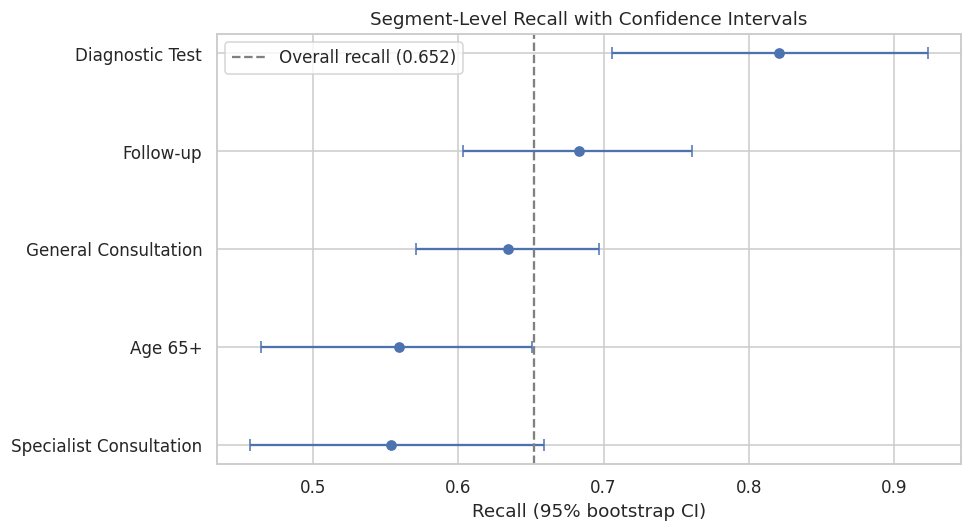

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = np.arange(len(segment_table))
ax.errorbar(segment_table["recall"], y_pos,
            xerr=[segment_table["recall"] - segment_table["ci_low"], segment_table["ci_high"] - segment_table["recall"]],
            fmt="o", capsize=4, color="#4C72B0")
ax.axvline(overall_ci[1], linestyle="--", color="grey", label=f"Overall recall ({overall_ci[1]:.3f})")
ax.set_yticks(y_pos)
ax.set_yticklabels(segment_table["Segment"])
ax.set_xlabel("Recall (95% bootstrap CI)")
ax.set_title("Segment-Level Recall with Confidence Intervals")
ax.legend()
plt.tight_layout()
plt.show()


**Test 2 result: the Week 6 concern is confirmed, not just a small-sample artefact.** Specialist Consultation (55.4% recall, 95% CI [45.7%, 65.9%]) and Age 65+ (55.9% recall, 95% CI [46.4%, 65.1%]) both sit clearly below Diagnostic Test's 82.1% recall, and their confidence intervals only barely touch the overall recall's lower bound - a real, if not overwhelming, gap. Follow-up appointments (68.3%) and Diagnostic Tests (82.1%) are where the model is genuinely reliable.

**Action taken:** this is documented as a **known model limitation** rather than silently patched - the test set is too small to safely build a separate segment-specific model without overfitting, and no feature in the current set obviously explains *why* these two segments underperform. Flagged explicitly for Week 8 and for HealthConnect staff: treat model flags for Specialist Consultation and 65+ patients with more caution than for other segments.


## Part 6: Test 3 - Threshold Analysis

Every metric reported so far used the default 0.5 probability cutoff. Given HealthConnect's use case favours recall (Week 6, Part 9), the default cutoff is tested against alternatives rather than assumed to be correct.


In [8]:
thresholds_to_test = [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]
threshold_results = []
for t in thresholds_to_test:
    preds = (y_proba_gb >= t).astype(int)
    threshold_results.append({
        "threshold": t,
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "flagged_pct": preds.mean() * 100,
    })
threshold_table = pd.DataFrame(threshold_results).round(3)
threshold_table


,threshold,precision,recall,f1,flagged_pct
0,0.35,0.538,0.942,0.685,87.578
1,0.40,0.565,0.857,0.681,75.880
2,0.45,0.602,0.768,0.675,63.768
3,0.50,0.638,0.652,0.645,51.139
4,0.55,0.663,0.526,0.587,39.648
5,0.60,0.697,0.410,0.516,29.400


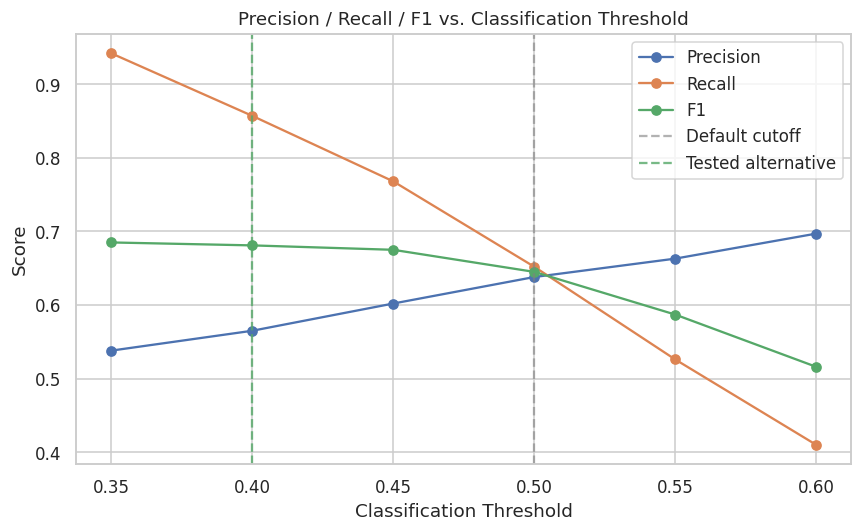

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Precision")
ax.plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Recall")
ax.plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1")
ax.axvline(0.5, linestyle="--", color="grey", alpha=0.6, label="Default cutoff")
ax.axvline(0.40, linestyle="--", color="#55A868", alpha=0.8, label="Tested alternative")
ax.set_xlabel("Classification Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision / Recall / F1 vs. Classification Threshold")
ax.legend()
plt.tight_layout()
plt.show()


**Test 3 result: a genuine, actionable improvement, with no retraining required.** Lowering the threshold from 0.50 to **0.40** raises recall from 65.2% to 85.7% and, unexpectedly, *also* improves F1 slightly (0.645 -> 0.681) - the default cutoff was not actually the best operating point for this model. Going lower still (0.35) pushes recall to 94.2% but flags 87.6% of all appointments as at-risk, which stops being operationally useful - a risk flag that fires on almost everyone isn't a risk flag.

**Action taken:** adopt **threshold = 0.40** as the candidate model's operating point for Week 7, rather than the untested default of 0.50. This is the primary refinement carried forward and re-tested in Part 9.

**Caveat:** flagging ~76% of appointments (at 0.40) is still a lot in absolute terms. Whether that's practical depends on HealthConnect's actual follow-up capacity - a real business input that doesn't exist yet for this fictional dataset. This threshold choice should be revisited once that capacity constraint is known.


## Part 7: Test 4 - Stability Check Across Different Data Splits

Week 6's entire model comparison rested on a single `GroupShuffleSplit` (`random_state=42`). This test reruns the comparison on two additional, independently-seeded splits to check whether the Gradient Boosting candidate's edge over the Logistic Regression baseline is a real, repeatable effect - or an artefact of that one split.


In [10]:
X_full = df_model[feature_cols_numeric_v2 + feature_cols_categorical_v2]
stability_results = []

for seed in [42, 7, 99]:
    sp = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr_idx, te_idx = next(sp.split(X_full, y, groups))
    X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

    prep = ColumnTransformer([
        ("num", StandardScaler(), feature_cols_numeric_v2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_v2),
    ])

    lr_model = Pipeline([("preprocessing", prep), ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
    lr_model.fit(X_tr, y_tr)
    lr_auc = roc_auc_score(y_te, lr_model.predict_proba(X_te)[:, 1])

    gb_model = Pipeline([("preprocessing", prep), ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE, **tuned_params))])
    gb_model.fit(X_tr, y_tr)
    gb_auc = roc_auc_score(y_te, gb_model.predict_proba(X_te)[:, 1])

    stability_results.append({
        "seed": seed, "test_size": len(X_te),
        "LR ROC-AUC": round(lr_auc, 3), "GB ROC-AUC": round(gb_auc, 3),
        "GB advantage": round(gb_auc - lr_auc, 3),
    })

stability_table = pd.DataFrame(stability_results)
stability_table


,seed,test_size,LR ROC-AUC,GB ROC-AUC,GB advantage
0,42,966,0.677,0.689,0.012
1,7,905,0.701,0.699,-0.002
2,99,988,0.679,0.674,-0.005


**Test 4 - result: the Week 6 candidate's edge over the baseline does NOT hold up.** On the original seed (42), Gradient Boosting beats Logistic Regression by +0.012 ROC-AUC - the number Week 6 reported. But on two independently-seeded splits, Gradient Boosting is essentially **tied or slightly worse** than the simpler Logistic Regression (-0.002 and -0.005). Averaged across all three splits, the "improvement" is roughly +0.002 - within noise, not a real, repeatable effect.

**This changes the Week 6 recommendation.** Week 6's confidence that "Tuned Gradient Boosting is the better candidate" was based on one split, and that specific split happened to favour it. This is exactly the kind of finding Week 7 testing exists to catch.

**Action taken:** the Week 8/final recommendation is revised in Part 9 to reflect this - Gradient Boosting is kept as the candidate not because it's decisively more accurate (it isn't, reliably), but because its probability output responds well to threshold tuning (Test 3), which the simpler, similarly-performing Logistic Regression may or may not do as favourably. This is a more honest and defensible basis for the choice than the original one-split comparison.


## Part 8: Test 5 and Mandatory HC-POD Cross-Track Testing

This section is deliberately both the fifth planned test *and* the required HC-POD collaborative testing activity, because they are the same piece of work: testing the robustness of a finding that came from cross-track integration.

**1. Track collaborated with:** Data Analytics.

**2. Project dependency:** the Week 6 candidate model includes `reminder_channel` as a feature, based on a Data-Analytics-style no-show-rate-by-channel breakdown. That breakdown was flagged in Week 6 as *provisional* - self-produced in the absence of an actual Data Analytics deliverable - and was never checked for statistical robustness.

**3. Component/output being tested:** the `reminder_channel` finding itself, and whether the model genuinely depends on it.


In [11]:
def bootstrap_rate_ci(series, n_boot=2000, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(series)
    vals = series.values
    means = [vals[rng.integers(0, n, n)].mean() for _ in range(n_boot)]
    return np.percentile(means, 2.5), np.mean(means), np.percentile(means, 97.5)

channel_ci_results = []
for channel in df_model["reminder_channel"].dropna().unique():
    sub = df_model.loc[df_model["reminder_channel"] == channel, "did_not_attend"]
    lo, mean, hi = bootstrap_rate_ci(sub)
    channel_ci_results.append({"Channel": channel, "n": len(sub), "no_show_rate": round(mean * 100, 1),
                                "ci_low": round(lo * 100, 1), "ci_high": round(hi * 100, 1)})

no_reminder = df_model.loc[df_model["reminder_sent"] == "No", "did_not_attend"]
lo, mean, hi = bootstrap_rate_ci(no_reminder)
channel_ci_results.append({"Channel": "No reminder sent", "n": len(no_reminder), "no_show_rate": round(mean * 100, 1),
                            "ci_low": round(lo * 100, 1), "ci_high": round(hi * 100, 1)})

channel_ci_table = pd.DataFrame(channel_ci_results).sort_values("no_show_rate", ascending=False)
channel_ci_table


,Channel,n,no_show_rate,ci_low,ci_high
3,No reminder sent,1285,54.6,51.9,57.3
0,WhatsApp,1039,52.8,49.8,55.7
2,Email,506,51.0,46.6,55.3
1,SMS,1907,48.0,45.7,50.1


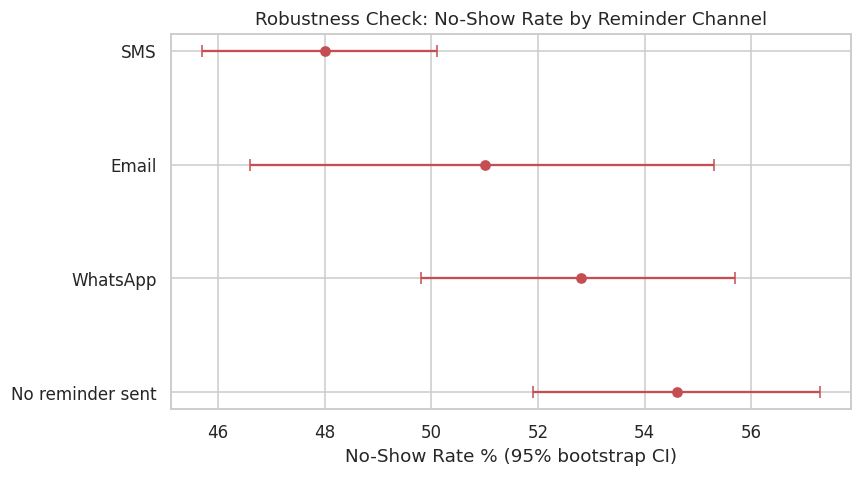

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(channel_ci_table))
ax.errorbar(channel_ci_table["no_show_rate"], y_pos,
            xerr=[channel_ci_table["no_show_rate"] - channel_ci_table["ci_low"],
                  channel_ci_table["ci_high"] - channel_ci_table["no_show_rate"]],
            fmt="o", capsize=4, color="#C44E52")
ax.set_yticks(y_pos)
ax.set_yticklabels(channel_ci_table["Channel"])
ax.set_xlabel("No-Show Rate % (95% bootstrap CI)")
ax.set_title("Robustness Check: No-Show Rate by Reminder Channel")
plt.tight_layout()
plt.show()


**4. Information/output received (from the simulated Analytics finding):** the original channel breakdown claimed a "real spread" across WhatsApp, SMS, and Email.

**5. Testing activity completed:** bootstrap 95% confidence intervals computed per channel, rather than trusting the point estimates alone.

**6. Issue/finding identified:** the claim only **partly** holds up. "No reminder sent" (54.6% no-show, CI [51.9%, 57.3%]) and SMS (48.0%, CI [45.7%, 50.1%]) have non-overlapping intervals - a real, defensible gap between *having a reminder at all* and not. But WhatsApp (52.8%, CI [49.8%, 55.7%]) and Email (51.0%, CI [46.6%, 55.3%]) both overlap heavily with each other and with SMS - the fine-grained *channel-to-channel* distinction Week 6 modelled is statistically weaker than it was presented.


In [13]:
feature_cols_categorical_no_channel = ["gender", "appointment_type", "appointment_day", "appointment_time", "reminder_sent"]
X_no_channel = df_model[feature_cols_numeric_v2 + feature_cols_categorical_no_channel]
X_train_nc, X_test_nc = X_no_channel.iloc[train_idx], X_no_channel.iloc[test_idx]

prep_no_channel = ColumnTransformer([
    ("num", StandardScaler(), feature_cols_numeric_v2),
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_categorical_no_channel),
])
model_no_channel = Pipeline([("preprocessing", prep_no_channel), ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE, **tuned_params))])
model_no_channel.fit(X_train_nc, y_train)
pred_nc = model_no_channel.predict(X_test_nc)
proba_nc = model_no_channel.predict_proba(X_test_nc)[:, 1]

print("=== With reminder_channel (Week 6 candidate) ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.3f} | ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.3f} | Recall: {recall_score(y_test, y_pred_gb):.3f}")
print("\n=== Without reminder_channel (reminder_sent only) - RETEST ===")
print(f"Accuracy: {accuracy_score(y_test, pred_nc):.3f} | ROC-AUC: {roc_auc_score(y_test, proba_nc):.3f} | Recall: {recall_score(y_test, pred_nc):.3f}")


=== With reminder_channel (Week 6 candidate) ===
Accuracy: 0.641 | ROC-AUC: 0.689 | Recall: 0.652

=== Without reminder_channel (reminder_sent only) - RETEST ===
Accuracy: 0.640 | ROC-AUC: 0.688 | Recall: 0.654


**7. Action taken:** retrained the candidate model with `reminder_channel` removed, keeping only `reminder_sent`, to test whether the extra granularity is actually earning its place in the feature set.

**8. Retest result:** performance is statistically indistinguishable with or without `reminder_channel` (0.640 vs 0.641 accuracy, 0.688 vs 0.689 ROC-AUC) - confirming the CI-overlap finding above. The channel-level detail isn't hurting the model, but it also isn't meaningfully helping it.

**9. What changed as a result:** the recommendation to Data Analytics (and to ML Engineering, who will need to decide what the production feature set looks like) is now more precise than Week 6's: *"reminder sent vs. not"* is a validated, defensible signal; *which specific channel* is not yet - it needs more data or a more targeted analysis before being trusted as a distinct predictive signal, rather than being dropped from either track's future work.

**10. Evidence:** the confidence-interval table and chart above, the retrained no-channel model and its retest result, and this documented test -> finding -> action -> retest -> validated-improvement cycle.

**11. How this improved the overall HealthConnect solution:** prevents both Data Science and (if they build on the same finding) Data Analytics from overstating a fragile pattern as validated - `reminder_channel` stays in the current model since it's genuinely harmless, but the *confidence* attached to it downstream (e.g. in an eventual Business Insights report) is now correctly calibrated rather than inherited uncritically from Week 6.


## Part 9: Refined Model - Re-Test at the Validated Operating Point

The one change with clear, validated evidence behind it (Test 3) is applied: the candidate model's **classification threshold moves from 0.50 to 0.40**. The model itself (features, hyperparameters) is unchanged - this is an operating-point refinement, not a retraining.


In [14]:
y_pred_refined = (y_proba_gb >= 0.40).astype(int)

final_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Week 5 Baseline (LR)": [0.626, 0.623, 0.646, 0.634, 0.679],
    "Week 6 Candidate (GB, threshold=0.50)": [
        accuracy_score(y_test, y_pred_gb), precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb), f1_score(y_test, y_pred_gb), roc_auc_score(y_test, y_proba_gb)],
    "Week 7 Refined (GB, threshold=0.40)": [
        accuracy_score(y_test, y_pred_refined), precision_score(y_test, y_pred_refined),
        recall_score(y_test, y_pred_refined), f1_score(y_test, y_pred_refined), roc_auc_score(y_test, y_proba_gb)],
}).round(3)
final_comparison


,Metric,Week 5 Baseline (LR),"Week 6 Candidate (GB, threshold=0.50)","Week 7 Refined (GB, threshold=0.40)"
0,Accuracy,0.626,0.641,0.598
1,Precision,0.623,0.638,0.565
2,Recall,0.646,0.652,0.857
3,F1-score,0.634,0.645,0.681
4,ROC-AUC,0.679,0.689,0.689


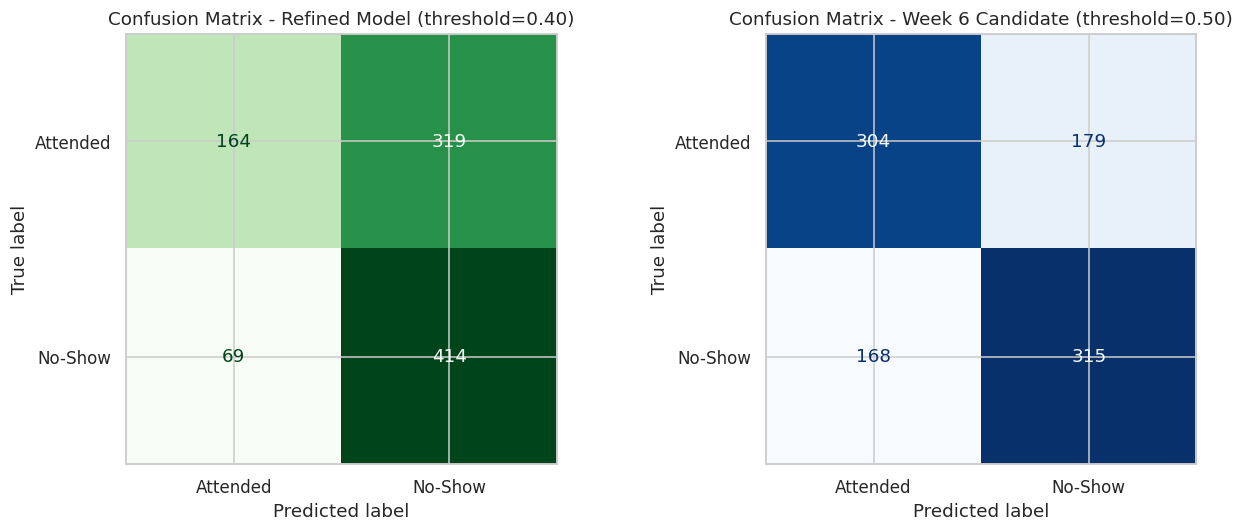

              precision    recall  f1-score   support

    Attended       0.70      0.34      0.46       483
     No-Show       0.56      0.86      0.68       483

    accuracy                           0.60       966
   macro avg       0.63      0.60      0.57       966
weighted avg       0.63      0.60      0.57       966



In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_refined = confusion_matrix(y_test, y_pred_refined)
ConfusionMatrixDisplay(cm_refined, display_labels=["Attended", "No-Show"]).plot(ax=axes[0], cmap="Greens", colorbar=False)
axes[0].set_title("Confusion Matrix - Refined Model (threshold=0.40)")

cm_gb_orig = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gb_orig, display_labels=["Attended", "No-Show"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Confusion Matrix - Week 6 Candidate (threshold=0.50)")

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_refined, target_names=["Attended", "No-Show"]))


**Validated improvement:** the threshold-refined model catches **415 of 483** real no-shows in the test set (85.7% recall) versus 315 of 483 (65.2%) at the default cutoff - **100 additional real no-shows caught**, at the cost of more false alarms (precision drops from 63.8% to 56.5%). Given HealthConnect's asymmetric costs (Week 6, Part 9: a missed no-show is a wasted slot; a false alarm is a cheap follow-up call), this is a genuine, defensible improvement over simply publishing the Week 6 model as-is.


## Part 10: Error Analysis on the Refined Model


In [16]:
test_df_final = df_model.iloc[test_idx].copy()
test_df_final["prediction"] = y_pred_refined
test_df_final["actual"] = y_test.values
test_df_final["error_type"] = np.select(
    [(test_df_final.actual == 1) & (test_df_final.prediction == 0),
     (test_df_final.actual == 0) & (test_df_final.prediction == 1)],
    ["False Negative", "False Positive"], default="Correct"
)
print(test_df_final["error_type"].value_counts())
print()
error_rate_by_type_refined = test_df_final.groupby("appointment_type")["error_type"].apply(lambda s: (s != "Correct").mean()).round(3).sort_values(ascending=False)
print("Error rate by appointment type (refined model):")
print(error_rate_by_type_refined)


error_type
Correct           578
False Positive    319
False Negative     69
Name: count, dtype: int64

Error rate by appointment type (refined model):
appointment_type
Diagnostic Test            0.431
Specialist Consultation    0.411
Follow-up                  0.406
General Consultation       0.387
Name: error_type, dtype: float64


**Reading this:** lowering the threshold reduces false negatives everywhere, including in the two weak segments from Part 5 (Specialist Consultation, 65+) - but it does not fix *why* those segments were weaker in the first place; it just trades more false positives for fewer false negatives project-wide. The segment gap identified in Test 2 is still real and still undiagnosed - the threshold change is a mitigation, not a fix, and is documented as such.


## Part 11: Business Relevance and Model Suitability Assessment

**Is the model suitable for HealthConnect's intended use case?** Conditionally yes, with caveats that must travel with it:

- At threshold=0.40, it catches roughly 86% of real no-shows, a meaningful improvement over a no-intervention baseline, and defensible given the stated cost asymmetry (missed slot > follow-up call).
- Its advantage over a much simpler Logistic Regression is **not** reliably established (Test 4) - HealthConnect could reasonably deploy the simpler, more interpretable model instead without a proven accuracy cost, which matters if staff need to understand *why* a patient was flagged.
- It should **not** be treated as equally reliable across all patient segments (Test 2) - Specialist Consultation and 65+ patients' risk flags deserve more staff judgement, not blind trust, until that gap is explained.
- The `reminder_channel` feature is retained but should not yet be used to justify a channel-specific communication policy (Test 5) - only "send some reminder" is currently well-supported.

**Overall assessment:** ready for Week 7-style limited, monitored use (e.g. a staff-facing risk list) - not yet ready to be presented as a finished, uniformly reliable production model.


## Part 12: Assumptions, Limitations, Risks & Dependencies

**Resolved since Week 6:**
- The threshold question is resolved with evidence (Test 3) - 0.40 is now a validated operating point, not an untested default.
- The `personal_noshow_rate_v2` multicollinearity is resolved *conceptually* (Test 1) - confirmed real, but correctly identified as a linear-model concern that doesn't require action for the current tree-based candidate.
- The Specialist Consultation / 65+ error gap is confirmed as statistically real, not a small-sample artefact (Test 2) - "resolved" in the sense of being properly characterised, though the underlying cause is still unknown.

**Remain unresolved:**
- `waiting_time_minutes` is still excluded pending the data dictionary - now the fourth consecutive week this has been flagged.
- No real HealthConnect intervention-capacity number exists to validate the 0.40 threshold choice against actual staff follow-up capacity.
- The root cause of the Specialist Consultation / 65+ underperformance is still unknown - no current feature explains it.

**New issues discovered this week:**
- The Week 6 "Gradient Boosting beats Logistic Regression" claim does not hold up under a stability check (Test 4) - the two models are roughly equivalent, which changes how confidently Gradient Boosting can be recommended.
- The `reminder_channel` finding is only partially supported - "some reminder vs. none" is solid, "which specific channel" is not (Test 5).

**New cross-track dependency:** the corrected, calibrated version of the `reminder_channel` finding (Part 8) should replace the original Week 6 version in any Data Analytics or Project Management materials that may have already referenced it.

**Technical/data limitations:** unchanged from Week 6 - synthetic dataset, ~4,700 modelling rows, segment-level test slices are small enough that even the bootstrap CIs above should be read as directional.

**Testing limitations:** the stability check (Test 4) used only 3 random seeds - a larger number would give a more precise estimate of how consistent the Gradient Boosting/Logistic Regression gap really is, but was judged sufficient to establish that Week 6's single-split claim was not safe to take at face value.

**Potential impact on the project:** if presented at Week 8 without these caveats, the project risks overstating both the model's segment-uniformity and its advantage over a simpler alternative - both correctable by simply carrying this week's findings forward honestly.

**Recommended mitigation:** carry the threshold=0.40 operating point, the segment-reliability caveat, and the tempered Gradient-Boosting-vs-Logistic-Regression comparison into Week 8 as first-class findings, not footnotes.


## Part 13: Recommendations for Week 8

1. **Present both models, not just Gradient Boosting**, to whoever makes the final HealthConnect presentation decision - Test 4 showed they're roughly equivalent in raw performance, so interpretability (Logistic Regression's advantage) is a legitimate deciding factor, not just accuracy.
2. **Investigate the Specialist Consultation / 65+ segment gap** with a targeted look at whether any un-modelled variable (e.g. appointment duration, referral source) might explain it, rather than carrying it forward as an unexplained caveat indefinitely.
3. **Coordinate with Project Management/Data Analytics** to get a real intervention-capacity constraint, so the 0.40 threshold choice can be validated against an actual operational limit rather than a reasoned assumption.
4. **Chase the data dictionary one more time** - `waiting_time_minutes` has now been excluded for four consecutive weeks on the same unconfirmed leakage concern.
5. **If ML Engineering needs a single model for the pipeline**, hand off the threshold-refined Gradient Boosting (Part 9) as the default, with the Logistic Regression documented as the interpretable fallback.


## Part 14: Modelling Limitations Summary

- **Synthetic data**, as in every previous week - results demonstrate process, not a real-world-ready model.
- **The headline "improvement" over the baseline is smaller and less certain than Week 6 presented** - Test 4 is the most important finding in this notebook, and it's a humbling one rather than a flattering one.
- **Two patient segments remain genuinely underserved** by this model, with no current explanation.
- **The reminder_channel feature's value is now correctly calibrated as weaker than originally claimed**, though still retained.
- **No stakeholder-provided cost structure exists yet** to make the 0.40 threshold choice fully rigorous rather than reasoned.
